#### Reference Hamiltonian

#### Import

In [18]:
import numpy as np
import json
import matplotlib.pyplot as plt
from src.interaction_utils import EffectiveInteractionOptimizer
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import qutip as qt
from src.utils import computational_basis
from qutip import fidelity
from NSMFermions.hamiltonian_utils import FermiHubbardHamiltonian
from NSMFermions.nuclear_physics_utils import (
    get_twobody_nuclearshell_model,
    SingleParticleState,
)
import numpy as np
import torch
from typing import Dict
import scipy
from NSMFermions.qml_models import AdaptVQEFermiHubbard
from NSMFermions.qml_utils.train import Fit
from NSMFermions.qml_utils.utils import configuration
from scipy.sparse.linalg import eigsh, expm_multiply
from tqdm import trange
import matplotlib.pyplot as plt
from NSMFermions.utils_quasiparticle_approximation import (
    QuasiParticlesConverter,
    HardcoreBosonsBasis,
    QuasiParticlesConverterOnlynnpp,
)
from src.utils import generate_particleconservation_basis, array_to_qutip

##### Parameters

In [19]:
data_onebody = np.load("data/matrix_elements_h_eff_2body/one_body_nn_sd.npz")
keys = data_onebody["keys"]
values = data_onebody["values"]
logical_qubits = 6

g_onebody = {}
diagonal_elements = np.zeros(logical_qubits)
g_matrix = np.zeros((logical_qubits, logical_qubits))
for a, key in enumerate(keys):
    i, j = key
    g_onebody[(i, j)] = values[a]
    if i != j:
        g_matrix[i, j] = values[a]
    if i == j:
        diagonal_elements[i] = values[a]


# get the computational basis of the space
basis = computational_basis(logical_qubits)

In [20]:
hamiltonian_xy = 0.0
for i in range(logical_qubits):
    for j in range(i + 1, logical_qubits):
        hamiltonian_xy += SpinOperator(
            [("x", i, "x", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
        hamiltonian_xy += SpinOperator(
            [("y", i, "y", j)],
            coupling=[0.5 * g_matrix[i, j]],
            size=logical_qubits,
            verbose=1,
        ).qutip_op
hamiltonian_z = 0.0
for i in range(logical_qubits):
    hamiltonian_z += SpinOperator(
        [("qz", i)], coupling=[0 * diagonal_elements[i]], size=logical_qubits, verbose=1
    ).qutip_op
nsm_quasiparticle_hamiltonian = hamiltonian_z + hamiltonian_xy

In [21]:
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

In [22]:
import numpy as np
from src.utils import computational_basis
import qutip as qt

# or just set n_qubits directly if you know it

N_op = sum(
    SpinOperator([("qz", i)], coupling=[1], size=logical_qubits).qutip_op
    for i in range(logical_qubits)
)
print(N_op.shape)

# shape (2**logical_qubits, logical_qubits)

# --- get all eigenstates ---
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Get all eigenstates
eigenvalues_nsm, eigenstates_nsm = nsm_quasiparticle_hamiltonian.eigenstates()

# Filter by <psi|N|psi> == 1
N_target = 1
sector_indices = [
    i
    for i, psi in enumerate(eigenstates_nsm)
    if abs(qt.expect(N_op, psi) - N_target) < 1e-6
]

eigenvalues_N1 = eigenvalues_nsm[sector_indices]
eigenstates_N1 = [eigenstates_nsm[i] for i in sector_indices]

# Lowest energy state in the N=1 sector
idx = sector_indices[np.argmin(eigenvalues_nsm[sector_indices])]
ground_state_N1 = eigenstates_nsm[idx]
ground_eigenvalue_N1 = eigenvalues_nsm[idx]

print("Ground state energy in N=1 sector:", ground_eigenvalue_N1)
print("Ground state in N=1 sector (in computational basis):")

(64, 64)
Ground state energy in N=1 sector: -4.902122346254491
Ground state in N=1 sector (in computational basis):



   Bitstring    |amp|^2    Re(amp)    Im(amp)
----------------------------------------------
      000001    0.19877    0.44584    0.00000
      000010    0.19509   -0.44170    0.00000
      000100    0.12320   -0.35099    0.00000
      001000    0.15964   -0.39955    0.00000
      010000    0.17491    0.41822    0.00000
      100000    0.14839   -0.38522    0.00000


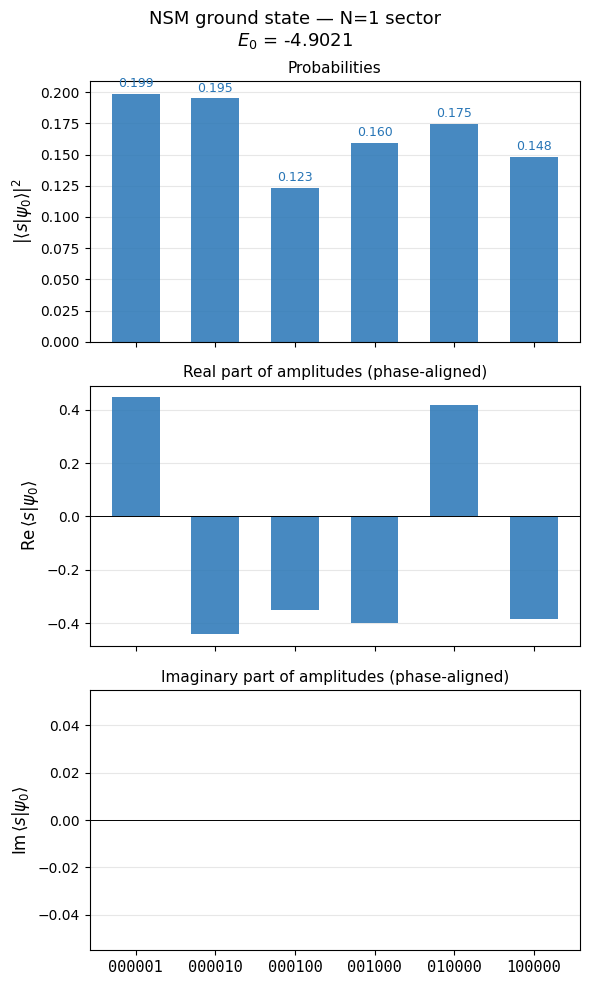

In [23]:
import matplotlib.pyplot as plt

# ── Amplitudes and probabilities of the NSM N=1 ground state ─────────────────

amps = ground_state_N1.full().flatten()  # complex amplitudes

# Phase-align: rotate so largest component is real+positive
idx_max = np.argmax(np.abs(amps))
amps_aligned = amps * np.exp(-1j * np.angle(amps[idx_max]))

probs = np.abs(amps_aligned) ** 2
re = amps_aligned.real
im = amps_aligned.imag

# Keep only N=1 sector bitstrings for plotting
basis_labels = ["".join(map(str, row)) for row in computational_basis(logical_qubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_n1 = probs[n1_mask]
re_n1 = re[n1_mask]
im_n1 = im[n1_mask]

# Print table
print(f"\n{'Bitstring':>12}  {'|amp|^2':>9}  {'Re(amp)':>9}  {'Im(amp)':>9}")
print("-" * 46)
for lbl, p, r, i_ in zip(labels_n1, probs_n1, re_n1, im_n1):
    print(f"{lbl:>12}  {p:>9.5f}  {r:>9.5f}  {i_:>9.5f}")

# ── Three-panel plot ──────────────────────────────────────────────────────────
CLR = "#2775b6"
x = np.arange(len(labels_n1))
width = 0.6

fig, axes = plt.subplots(3, 1, figsize=(max(6, len(labels_n1) * 0.9), 10), sharex=True)
fig.suptitle(
    f"NSM ground state — N=1 sector\n" f"$E_0$ = {ground_eigenvalue_N1:.4f}",
    fontsize=13,
)

# Panel 1: probabilities
ax = axes[0]
bars = ax.bar(x, probs_n1, width, color=CLR, alpha=0.85)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
for bar, v in zip(bars, probs_n1):
    if v > 0.005:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.003,
            f"{v:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color=CLR,
        )

# Panel 2: real parts
ax = axes[1]
bars = ax.bar(x, re_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Panel 3: imaginary parts
ax = axes[2]
bars = ax.bar(x, im_n1, width, color=CLR, alpha=0.85)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Im}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Imaginary part of amplitudes (phase-aligned)", fontsize=11)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)

plt.tight_layout()
plt.savefig("nsm_gs_wavefunction.pdf", bbox_inches="tight")
plt.show()

#### Getting the freaking effective Interaction

Optimal drive parameters: [ 0.90513022 -1.02535363  0.96153052  0.79417758  1.10508836 -1.13502171]
Optimized effective interaction matrix:
 [[ 0.00000000e+00  2.38278549e-01 -4.64010329e-01  1.81947762e-01
   9.31196814e-01  4.25607480e-01]
 [ 2.38278549e-01  0.00000000e+00  1.26008806e-01 -8.64690260e-02
  -5.12896679e-04  2.35762770e-01]
 [-4.64010329e-01  1.26008806e-01  0.00000000e+00  1.37155905e-01
  -3.27870148e-01 -7.07116593e-01]
 [ 1.81947762e-01 -8.64690260e-02  1.37155905e-01  0.00000000e+00
  -1.59923018e-01  1.83695413e-01]
 [ 9.31196814e-01 -5.12896679e-04 -3.27870148e-01 -1.59923018e-01
   0.00000000e+00  3.53399274e-01]
 [ 4.25607480e-01  2.35762770e-01 -7.07116593e-01  1.83695413e-01
   3.53399274e-01  0.00000000e+00]]


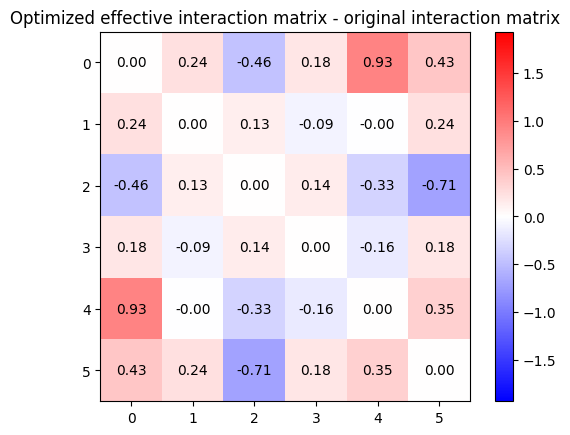

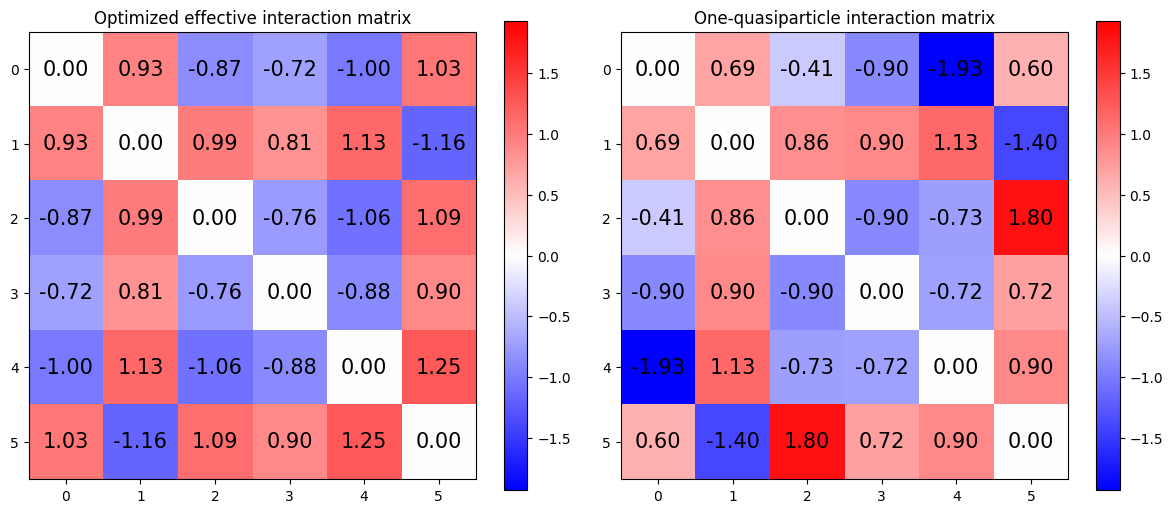

In [24]:
OptimalFieldBe6 = EffectiveInteractionOptimizer(
    nqubit=logical_qubits, n_restarts=100, scale=2.0, ftol=1e-15, gtol=1e-10
)

d_opt, result = OptimalFieldBe6.optimize_rank1(g_matrix)
print("Optimal drive parameters:", d_opt)
print(
    "Optimized effective interaction matrix:\n",
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
)
plt.imshow(
    OptimalFieldBe6.reconstructed(d_opt) - g_matrix,
    cmap="bwr",
    vmin=-np.max(np.abs(g_matrix)),
    vmax=np.max(np.abs(g_matrix)),
)
for i in range(logical_qubits):
    for j in range(logical_qubits):
        plt.text(
            j,
            i,
            f"{OptimalFieldBe6.reconstructed(d_opt)[i,j]-g_matrix[i,j]:.2f}",
            ha="center",
            va="center",
            color="black",
        )
plt.colorbar()
plt.title("Optimized effective interaction matrix - original interaction matrix")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmax = np.max(np.abs(g_matrix))
matrices = [OptimalFieldBe6.reconstructed(d_opt), g_matrix]
titles = [
    "Optimized effective interaction matrix",
    "One-quasiparticle interaction matrix",
]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.imshow(mat, cmap="bwr", vmin=-vmax, vmax=vmax)
    for i in range(logical_qubits):
        for j in range(logical_qubits):
            ax.text(
                j,
                i,
                f"{mat[i,j]:.2f}",
                ha="center",
                va="center",
                color="black",
                fontsize=15,
            )
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

#### D-WAVE Embedding and effective Hamiltonians

In [25]:
import minorminer
import dwave_networkx as dnx
import networkx as nx

# K4: fully connected, 4 nodes = 6 edges
K4 = nx.complete_graph(6)
print("Problem edges:", list(K4.edges()))

# Hardware graph
hardware = dnx.pegasus_graph(16)

import minorminer

embedding = minorminer.find_embedding(K4, hardware)


# Manual verification
def check_embedding(embedding, problem_graph, hardware_graph):
    # Check 1: all chains connected in hardware
    for node, chain in embedding.items():
        subgraph = hardware_graph.subgraph(chain)
        if not nx.is_connected(subgraph):
            print(f"✗ q{node}: chain {chain} is NOT connected in hardware")
            return False

    # Check 2: every problem edge has a coupler between chains
    for u, v in problem_graph.edges():
        chain_u = set(embedding[u])
        chain_v = set(embedding[v])
        has_coupler = any(
            hardware_graph.has_edge(a, b) for a in chain_u for b in chain_v
        )
        if not has_coupler:
            print(
                f"✗ edge ({u},{v}): no coupler between chains {chain_u} and {chain_v}"
            )
            return False

    print("✓ Valid embedding")
    print(f"  Chain lengths: { {f'q{k}': len(v) for k,v in embedding.items()} }")
    return True


check_embedding(embedding, K4, hardware)

Problem edges: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (1, 2), (1, 3), (1, 4), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (3, 5), (4, 5)]
✓ Valid embedding
  Chain lengths: {'q0': 1, 'q1': 1, 'q2': 1, 'q3': 1, 'q4': 2, 'q5': 2}


True

/tmp/ipykernel_16492/506417983.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


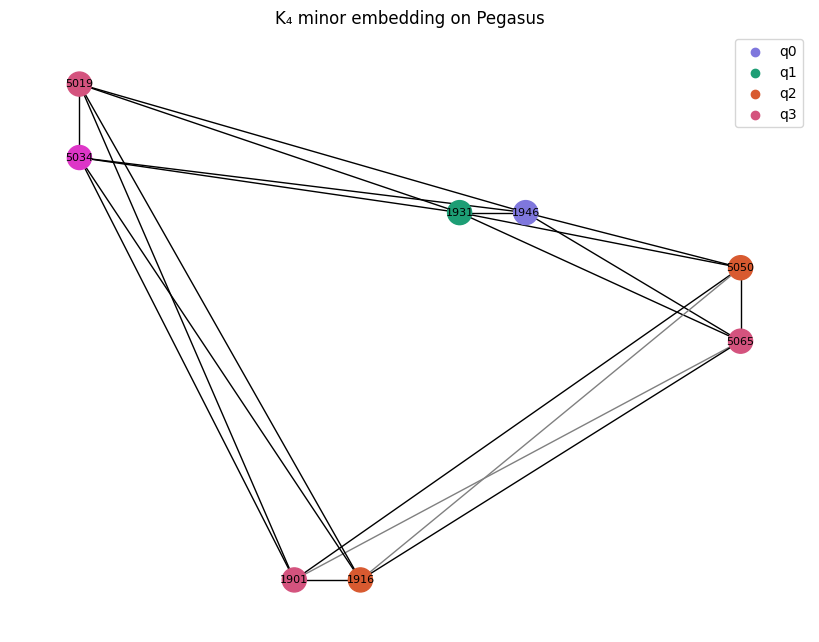

In [26]:
import matplotlib.pyplot as plt
import dwave_networkx as dnx
import minorminer
import networkx as nx

K4 = nx.complete_graph(6)
hardware = dnx.pegasus_graph(16)
embedding = minorminer.find_embedding(K4, hardware)

# Extract only the hardware nodes/edges used
used_nodes = [node for chain in embedding.values() for node in chain]
used_edges = []
for u, v in K4.edges():
    for a in embedding[u]:
        for b in embedding[v]:
            if hardware.has_edge(a, b):
                used_edges.append((a, b))

# Color by logical qubit
colors = [
    "#7F77DD",
    "#1D9E75",
    "#D85A30",
    "#D4537E",
    "#DD36C7",
    "#D4537E",
]  # purple, teal, coral, pink
node_colors = {}
for i, chain in embedding.items():
    for node in chain:
        node_colors[node] = colors[i]

subgraph = hardware.subgraph(used_nodes).copy()
for u, v in used_edges:
    if not subgraph.has_edge(u, v):
        subgraph.add_edge(u, v)

pos = dnx.pegasus_layout(subgraph)

plt.figure(figsize=(8, 6))
nx.draw(
    subgraph,
    pos,
    node_color=[node_colors[n] for n in subgraph.nodes()],
    edge_color=[
        "gray" if (u, v) not in used_edges and (v, u) not in used_edges else "black"
        for u, v in subgraph.edges()
    ],
    node_size=300,
    with_labels=True,
    font_size=8,
)
plt.title("K₄ minor embedding on Pegasus")
plt.legend(handles=[plt.scatter([], [], c=colors[i], label=f"q{i}") for i in range(4)])
plt.tight_layout()
plt.savefig("embedding.png", dpi=150)
plt.show()

In [27]:
print(used_nodes)
print(used_edges)

# build index map: physical qubit → local index 0..7
phys_to_idx = {phys: idx for idx, phys in enumerate(used_nodes)}

print("=== Physical → Local index ===")
for phys, idx in phys_to_idx.items():
    print(f"  {phys} → {idx}")

print("\n=== Chains (local indices) ===")
mapping = []
for logical, chain in embedding.items():
    local_chain = [phys_to_idx[p] for p in chain]
    mapping.append(local_chain)
    print(f"  q{logical} → {local_chain}")

print("\n=== Edges (local indices) ===")
local_edges = [(phys_to_idx[u], phys_to_idx[v]) for u, v in used_edges]
print(local_edges)

[1946, 1931, 5050, 1916, 5065, 1901, 5034, 5019]
[(1946, 1931), (1946, 5050), (1946, 5065), (1946, 5034), (1946, 5019), (1931, 5050), (1931, 5065), (1931, 5034), (1931, 5019), (5050, 5065), (5050, 1901), (1916, 5065), (1916, 1901), (1916, 5034), (1916, 5019), (1901, 5034), (1901, 5019), (5034, 5019)]
=== Physical → Local index ===
  1946 → 0
  1931 → 1
  5050 → 2
  1916 → 3
  5065 → 4
  1901 → 5
  5034 → 6
  5019 → 7

=== Chains (local indices) ===
  q0 → [0]
  q1 → [1]
  q2 → [2, 3]
  q3 → [4, 5]
  q4 → [6]
  q5 → [7]

=== Edges (local indices) ===
[(0, 1), (0, 2), (0, 4), (0, 6), (0, 7), (1, 2), (1, 4), (1, 6), (1, 7), (2, 4), (2, 5), (3, 4), (3, 5), (3, 6), (3, 7), (5, 6), (5, 7), (6, 7)]


Encoding

In [28]:
# chains dict: already comes from embedding + phys_to_idx
chains = {
    logical: [phys_to_idx[p] for p in chain] for logical, chain in embedding.items()
}

# intra_edges: pairs within the same chain that are connected in hardware
intra_edges = []
for logical, chain in chains.items():
    local_chain = [phys_to_idx[p] for p in embedding[logical]]
    for k in range(len(local_chain) - 1):
        intra_edges.append((local_chain[k], local_chain[k + 1]))

# inter_edges: all local_edges minus intra_edges
intra_set = set(map(frozenset, intra_edges))
inter_edges = [(u, v) for u, v in local_edges if frozenset((u, v)) not in intra_set]

print("Chains:", chains)
print("Intra edges:", intra_edges)
print("Inter edges:", inter_edges)
print("Representatives:", {l: chain[0] for l, chain in chains.items()})

Chains: {0: [0], 1: [1], 2: [2, 3], 3: [4, 5], 4: [6], 5: [7]}
Intra edges: [(2, 3), (4, 5)]
Inter edges: [(0, 1), (0, 2), (0, 4), (0, 6), (0, 7), (1, 2), (1, 4), (1, 6), (1, 7), (2, 4), (2, 5), (3, 4), (3, 5), (3, 6), (3, 7), (5, 6), (5, 7), (6, 7)]
Representatives: {0: 0, 1: 1, 2: 2, 3: 4, 4: 6, 5: 7}


In [75]:
# physical qubit -> logical qubit lookup
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

In [76]:
# for each logical pair, find the physical coupler
logical_pair_to_physical_coupler = {}
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in logical_pair_to_physical_coupler:
        logical_pair_to_physical_coupler[pair] = (u, v)

print("=== Logical pair → physical coupler ===")
for pair, (u, v) in logical_pair_to_physical_coupler.items():
    lu, lv = tuple(pair)
    print(f"  q{lu}-q{lv}: physical ({u},{v})")

=== Logical pair → physical coupler ===
  q0-q1: physical (0,1)
  q0-q2: physical (0,2)
  q0-q3: physical (0,4)
  q0-q4: physical (0,6)
  q0-q5: physical (0,7)
  q1-q2: physical (1,2)
  q1-q3: physical (1,4)
  q1-q4: physical (1,6)
  q1-q5: physical (1,7)
  q2-q3: physical (2,4)
  q2-q4: physical (3,6)
  q2-q5: physical (3,7)
  q3-q4: physical (5,6)
  q3-q5: physical (5,7)
  q4-q5: physical (6,7)


In [ ]:
import qutip as qt
from ManyBodyQutip.qutip_class import SpinOperator, SpinHamiltonian
import numpy as np
from collections import defaultdict

gamma = 40
J_F = 200
n_physical = 8
N_tot = 1

identity = qt.tensor([qt.qeye(2)] * n_physical)

# build a lookup: logical qubit -> representative physical qubit
representatives = {logical: chain[0] for logical, chain in chains.items()}

# build a lookup: physical qubit -> logical qubit
phys_to_logical = {}
for logical, chain in chains.items():
    for p in chain:
        phys_to_logical[p] = logical

# recheck: with gamma=20, N_tot=1
# gamma*(1 - 2*N_tot) = 20*(1-2) = -20  ← this is correct
# but ZZ coupling 2*gamma = 40 per pair

# the problem is that for chains, BOTH physical qubits are being
# set in the one-hot state. The constraint must act on representatives ONLY.

# verify representatives
print("Representatives:", representatives)
# should be: {0:0, 1:1, 2:2, 3:4, 4:6, 5:7}
# q2 representative is 2 (not both 2 and 3)
# q3 representative is 4 (not both 4 and 5)

# rebuild hamiltonian_zz using ONLY representatives
hamiltonian_zz = 0.0
added_pairs = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs:
        continue
    added_pairs.add(pair)
    # use the actual hardware coupler (u,v), not the representatives
    print(f"  logical (q{lu},q{lv}): physical coupler ({u},{v})")
    hamiltonian_zz += SpinOperator(
        [("qz", u, "qz", v)], coupling=[2 * gamma], size=n_physical, verbose=0
    ).qutip_op

print(f"ZZ pairs added: {len(added_pairs)}")


# track which physical qubits carry ZZ for each logical qubit
logical_to_physical_in_zz = defaultdict(set)
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair not in added_pairs:
        continue
    logical_to_physical_in_zz[lu].add(u)
    logical_to_physical_in_zz[lv].add(v)

# linear term: constraint + external field, split across physical qubits
hamiltonian_z = 0.0
for logical in range(6):
    phys_set = logical_to_physical_in_zz[logical]
    n_phys = len(phys_set)

    # constraint part: gamma*(1-2*N_tot) per logical qubit
    h_constraint = gamma * (1 - 2 * N_tot)

    h_total_logical = h_constraint

    # split equally across all physical qubits of this logical qubit
    for p in phys_set:
        hamiltonian_z += SpinOperator(
            [("qz", p)], coupling=[h_total_logical / n_phys], size=n_physical, verbose=0
        ).qutip_op

identity = qt.tensor([qt.qeye(2)] * n_physical)
H_constraint = hamiltonian_zz + hamiltonian_z + gamma * (N_tot**2) * identity


H_ferro = 0.0
for a, b in intra_edges:
    H_ferro += SpinOperator(
        [("qz", a, "qz", b)], coupling=[-4 * J_F], size=n_physical, verbose=0
    ).qutip_op
    H_ferro += SpinOperator(
        [("qz", a)], coupling=[2 * J_F], size=n_physical, verbose=0
    ).qutip_op
    H_ferro += SpinOperator(
        [("qz", b)], coupling=[2 * J_F], size=n_physical, verbose=0
    ).qutip_op
    H_ferro += (-J_F) * identity


longitudinal_hamiltonian = H_constraint + H_ferro

# check spectrum
evals = np.sort(np.real(longitudinal_hamiltonian.eigenenergies()))
print("Spectrum (first 8):", evals[:8])
print("Ground state degeneracy:", np.sum(np.isclose(evals, evals[0])))

Representatives: {0: 0, 1: 1, 2: 2, 3: 4, 4: 6, 5: 7}
  logical (q0,q1): physical coupler (0,1)
  logical (q0,q2): physical coupler (0,2)
  logical (q0,q3): physical coupler (0,4)
  logical (q0,q4): physical coupler (0,6)
  logical (q0,q5): physical coupler (0,7)
  logical (q1,q2): physical coupler (1,2)
  logical (q1,q3): physical coupler (1,4)
  logical (q1,q4): physical coupler (1,6)
  logical (q1,q5): physical coupler (1,7)
  logical (q2,q3): physical coupler (2,4)
  logical (q2,q4): physical coupler (3,6)
  logical (q2,q5): physical coupler (3,7)
  logical (q3,q4): physical coupler (5,6)
  logical (q3,q5): physical coupler (5,7)
  logical (q4,q5): physical coupler (6,7)
ZZ pairs added: 15
Spectrum (first 8): [-160. -160. -160. -160. -160. -160. -120. -120.]
Ground state degeneracy: 6


In [163]:
# get eigenvalues and eigenstates
evals, evecs = longitudinal_hamiltonian.eigenstates()

print("=== Lowest energy states ===")
for k in range(20):
    energy = evals[k]
    state = evecs[k]

    # get probabilities over computational basis
    probs = np.abs(state.full().flatten()) ** 2
    dominant_idx = np.argmax(probs)

    # convert to bitstring (8 qubits)
    bitstring = format(dominant_idx, f"0{n_physical}b")

    print(
        f"  E[{k}] = {energy:.4f} | bitstring: {bitstring} | prob: {probs[dominant_idx]:.4f}"
    )

=== Lowest energy states ===
  E[0] = -160.0000 | bitstring: 00000001 | prob: 1.0000
  E[1] = -160.0000 | bitstring: 00000010 | prob: 1.0000
  E[2] = -160.0000 | bitstring: 00001100 | prob: 1.0000
  E[3] = -160.0000 | bitstring: 00110000 | prob: 1.0000
  E[4] = -160.0000 | bitstring: 01000000 | prob: 1.0000
  E[5] = -160.0000 | bitstring: 10000000 | prob: 1.0000
  E[6] = -120.0000 | bitstring: 00000000 | prob: 1.0000
  E[7] = -120.0000 | bitstring: 00001101 | prob: 1.0000
  E[8] = -120.0000 | bitstring: 00001110 | prob: 1.0000
  E[9] = -120.0000 | bitstring: 00000011 | prob: 1.0000
  E[10] = -120.0000 | bitstring: 00110001 | prob: 1.0000
  E[11] = -120.0000 | bitstring: 00110010 | prob: 1.0000
  E[12] = -120.0000 | bitstring: 00111100 | prob: 1.0000
  E[13] = -120.0000 | bitstring: 01000001 | prob: 1.0000
  E[14] = -120.0000 | bitstring: 01000010 | prob: 1.0000
  E[15] = -120.0000 | bitstring: 01001100 | prob: 1.0000
  E[16] = -120.0000 | bitstring: 01110000 | prob: 1.0000
  E[17] = -1

In [164]:
print("\n=== Chain qubit used for each logical pair ===")
added_pairs2 = set()
for u, v in inter_edges:
    lu = phys_to_logical[u]
    lv = phys_to_logical[v]
    if lu == lv:
        continue
    pair = frozenset((lu, lv))
    if pair in added_pairs2:
        continue
    added_pairs2.add(pair)
    ru, rv = representatives[lu], representatives[lv]
    flag = ""
    if u != ru or v != rv:
        flag = "  ← NON-REPRESENTATIVE"
    print(f"  logical (q{lu},q{lv}): physical ({u},{v}) | reps ({ru},{rv}){flag}")


=== Chain qubit used for each logical pair ===
  logical (q0,q1): physical (0,1) | reps (0,1)
  logical (q0,q2): physical (0,2) | reps (0,2)
  logical (q0,q3): physical (0,4) | reps (0,4)
  logical (q0,q4): physical (0,6) | reps (0,6)
  logical (q0,q5): physical (0,7) | reps (0,7)
  logical (q1,q2): physical (1,2) | reps (1,2)
  logical (q1,q3): physical (1,4) | reps (1,4)
  logical (q1,q4): physical (1,6) | reps (1,6)
  logical (q1,q5): physical (1,7) | reps (1,7)
  logical (q2,q3): physical (2,4) | reps (2,4)
  logical (q2,q4): physical (3,6) | reps (2,6)  ← NON-REPRESENTATIVE
  logical (q2,q5): physical (3,7) | reps (2,7)  ← NON-REPRESENTATIVE
  logical (q3,q4): physical (5,6) | reps (4,6)  ← NON-REPRESENTATIVE
  logical (q3,q5): physical (5,7) | reps (4,7)  ← NON-REPRESENTATIVE
  logical (q4,q5): physical (6,7) | reps (6,7)


In [165]:
# check each term independently
print("=== H_constraint diagonal ===")
diag_constraint = np.real(longitudinal_hamiltonian.full().diagonal())
idx_sorted = np.argsort(diag_constraint)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_constraint[k]:.4f}")

print("\n=== H_ferro diagonal ===")
diag_ferro = np.real(H_ferro.full().diagonal())
idx_sorted = np.argsort(diag_ferro)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    print(f"  {bitstring} | E={diag_ferro[k]:.4f}")

print("\n=== H_total diagonal ===")
diag_total = np.real(longitudinal_hamiltonian.full().diagonal())
idx_sorted = np.argsort(diag_total)
for k in idx_sorted[:6]:
    bitstring = format(k, f"0{n_physical}b")[::-1]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  {bitstring} | N={n_particles} | E={diag_total[k]:.4f}")

# also print current parameter values
print(f"\ngamma={gamma}, J_F={J_F}, N_tot={N_tot}")
print(f"chains: {chains}")
print(f"intra_edges: {intra_edges}")
print(f"representatives: {representatives}")

=== H_constraint diagonal ===
  10000000 | N=1 | E=-160.0000
  01000000 | N=1 | E=-160.0000
  00110000 | N=2 | E=-160.0000
  00001100 | N=2 | E=-160.0000
  00000010 | N=1 | E=-160.0000
  00000001 | N=1 | E=-160.0000

=== H_ferro diagonal ===
  00000000 | E=-160.0000
  10000000 | E=-160.0000
  01000000 | E=-160.0000
  11000000 | E=-160.0000
  00110000 | E=-160.0000
  10110000 | E=-160.0000

=== H_total diagonal ===
  10000000 | N=1 | E=-160.0000
  01000000 | N=1 | E=-160.0000
  00110000 | N=2 | E=-160.0000
  00001100 | N=2 | E=-160.0000
  00000010 | N=1 | E=-160.0000
  00000001 | N=1 | E=-160.0000

gamma=40, J_F=80, N_tot=1
chains: {0: [0], 1: [1], 2: [2, 3], 3: [4, 5], 4: [6], 5: [7]}
intra_edges: [(2, 3), (4, 5)]
representatives: {0: 0, 1: 1, 2: 2, 3: 4, 4: 6, 5: 7}


In [166]:
print("=== Constraint energy for one-hot states ===")
for logical in range(6):
    # construct one-hot: only representative of this logical qubit is 1
    idx = 0
    for l, chain in chains.items():
        if l == logical:
            for p in chain:
                idx += 1 << p  # set bit p
    bitstring = format(idx, f"0{n_physical}b")[::-1]
    e = diag_constraint[idx]
    n_particles = sum(int(b) for b in bitstring)
    print(f"  q{logical} occupied: {bitstring} | N={n_particles} | E={e:.4f}")

print("\n=== Constraint energy for vacuum ===")
print(f"  E(vacuum) = {diag_constraint[0]:.4f}")

print("\n=== Constraint energy for two-particle states ===")
for i in range(6):
    for j in range(i + 1, 6):
        idx = 0
        for p in chains[i]:
            idx += 1 << p
        for p in chains[j]:
            idx += 1 << p
        e = diag_constraint[idx]
        print(f"  q{i},q{j}: E={e:.4f}")

=== Constraint energy for one-hot states ===
  q0 occupied: 10000000 | N=1 | E=-160.0000
  q1 occupied: 01000000 | N=1 | E=-160.0000
  q2 occupied: 00110000 | N=2 | E=-160.0000
  q3 occupied: 00001100 | N=2 | E=-160.0000
  q4 occupied: 00000010 | N=1 | E=-160.0000
  q5 occupied: 00000001 | N=1 | E=-160.0000

=== Constraint energy for vacuum ===
  E(vacuum) = -120.0000

=== Constraint energy for two-particle states ===
  q0,q1: E=-120.0000
  q0,q2: E=-120.0000
  q0,q3: E=-120.0000
  q0,q4: E=-120.0000
  q0,q5: E=-120.0000
  q1,q2: E=-120.0000
  q1,q3: E=-120.0000
  q1,q4: E=-120.0000
  q1,q5: E=-120.0000
  q2,q3: E=-120.0000
  q2,q4: E=-120.0000
  q2,q5: E=-120.0000
  q3,q4: E=-120.0000
  q3,q5: E=-120.0000
  q4,q5: E=-120.0000


##### Adding the transverse field

In [167]:
d_phys = np.zeros(n_physical)
for logical, chain in chains.items():
    if len(chain) == 1:
        d_phys[chain[0]] = d_opt[logical] / np.sqrt(2)
    else:
        d_logical = d_opt[logical] / np.sqrt(2)
        magnitude = np.sqrt(np.abs(d_logical) * J_F)
        d_phys[chain[0]] = +magnitude
        d_phys[chain[1]] = np.sign(d_logical) * magnitude

# transverse field on physical qubits
transverse_hamiltonian = 0.0
for phys_idx in range(n_physical):
    transverse_hamiltonian += SpinOperator(
        [("x", phys_idx)], coupling=[d_phys[phys_idx]], size=n_physical, verbose=0
    ).qutip_op

In [168]:
# full hamiltonian with transverse field
H_total = H_constraint + H_ferro + transverse_hamiltonian

# diagonalize
evals, evecs = H_total.eigenstates()

print("=== Ground state analysis ===")
print(f"Ground state energy: {np.real(evals[0]):.6f}")
print(f"First excited energy: {np.real(evals[1]):.6f}")
print(f"Gap: {np.real(evals[1] - evals[0]):.6f}")

print("\n=== Ground state bitstring decomposition ===")
gs = evecs[0]
probs = np.abs(gs.full().flatten()) ** 2

# sort by probability
sorted_idx = np.argsort(probs)[::-1]

print(f"{'bitstring':>12}  {'prob':>8}  {'logical meaning'}")
print("-" * 50)
for idx in sorted_idx[:10]:  # top 10 components
    if probs[idx] < 1e-6:
        break
    bitstring = format(idx, f"0{n_physical}b")[::-1]  # reverse for q0=LSB

    # identify which logical qubit is occupied
    occupied_physical = [i for i, b in enumerate(bitstring) if b == "1"]
    occupied_logical = []
    for phys in occupied_physical:
        for logical, chain in chains.items():
            if phys in chain:
                occupied_logical.append(f"q{logical}")

    print(f"  {bitstring}  {probs[idx]:>8.4f}  {occupied_logical}")

=== Ground state analysis ===
Ground state energy: -161.343188
First excited energy: -161.205908
Gap: 0.137281

=== Ground state bitstring decomposition ===
   bitstring      prob  logical meaning
--------------------------------------------------
  10000000    0.2144  ['q0']
  01000000    0.2079  ['q1']
  00000010    0.1907  ['q4']
  00000001    0.1615  ['q5']
  00001100    0.1185  ['q3', 'q3']
  00110000    0.0950  ['q2', 'q2']
  00000000    0.0017  []
  10000100    0.0006  ['q0', 'q3']
  01000100    0.0006  ['q1', 'q3']
  00001010    0.0006  ['q3', 'q4']


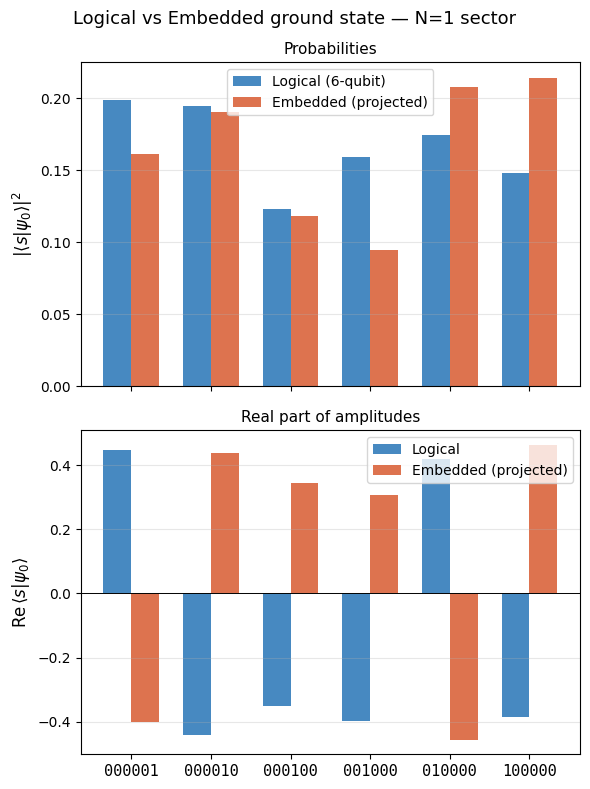


Fidelity (logical vs embedded projected): 0.970292


In [169]:
def embedded_to_logical(bitstring_8, chains):
    """
    Convert 8-qubit physical bitstring to 6-qubit logical bitstring.
    Returns None if any chain is broken (qubits disagree).
    """
    logical_bits = []
    for logical in range(len(chains)):
        chain = chains[logical]
        bits_in_chain = [int(bitstring_8[p]) for p in chain]
        if len(set(bits_in_chain)) > 1:
            return None  # broken chain — not in logical subspace
        logical_bits.append(bits_in_chain[0])
    return "".join(map(str, logical_bits))


# embedded ground state
gs_emb = evecs[0]
amps_emb = gs_emb.full().flatten()

# phase align
idx_max = np.argmax(np.abs(amps_emb))
amps_emb_aligned = amps_emb * np.exp(-1j * np.angle(amps_emb[idx_max]))

# project onto logical basis
logical_amp = {}
for idx in range(2**n_physical):
    bitstring_8 = format(idx, f"0{n_physical}b")[::-1]  # q0=LSB
    logical_bits = embedded_to_logical(bitstring_8, chains)
    if logical_bits is not None:
        if logical_bits not in logical_amp:
            logical_amp[logical_bits] = 0.0
        logical_amp[logical_bits] += amps_emb_aligned[idx]

# now compare with logical ground state
amps_logical = ground_state_N1.full().flatten()
idx_max_l = np.argmax(np.abs(amps_logical))
amps_logical_aligned = amps_logical * np.exp(-1j * np.angle(amps_logical[idx_max_l]))

basis_labels = ["".join(map(str, row)) for row in computational_basis(logical_qubits)]
n1_mask = np.array([sum(int(b) for b in lbl) == 1 for lbl in basis_labels])
labels_n1 = [l for l, m in zip(basis_labels, n1_mask) if m]

probs_logical = np.abs(amps_logical_aligned) ** 2
probs_emb_projected = np.array([np.abs(logical_amp.get(l, 0)) ** 2 for l in labels_n1])
re_logical = amps_logical_aligned.real[n1_mask]
re_emb = np.array([logical_amp.get(l, 0).real for l in labels_n1])

# ── comparison plot ──────────────────────────────────────────────────────────
CLR_LOG = "#2775b6"
CLR_EMB = "#D85A30"
x = np.arange(len(labels_n1))
width = 0.35

fig, axes = plt.subplots(2, 1, figsize=(max(6, len(labels_n1) * 0.9), 8), sharex=True)
fig.suptitle("Logical vs Embedded ground state — N=1 sector", fontsize=13)

# Panel 1: probabilities
ax = axes[0]
ax.bar(
    x - width / 2,
    probs_logical[n1_mask],
    width,
    color=CLR_LOG,
    alpha=0.85,
    label="Logical (6-qubit)",
)
ax.bar(
    x + width / 2,
    probs_emb_projected,
    width,
    color=CLR_EMB,
    alpha=0.85,
    label="Embedded (projected)",
)
ax.set_ylabel(r"$|\langle s|\psi_0\rangle|^2$", fontsize=12)
ax.set_title("Probabilities", fontsize=11)
ax.legend()
ax.yaxis.grid(True, alpha=0.3)

# Panel 2: real part
ax = axes[1]
ax.bar(x - width / 2, re_logical, width, color=CLR_LOG, alpha=0.85, label="Logical")
ax.bar(
    x + width / 2,
    re_emb,
    width,
    color=CLR_EMB,
    alpha=0.85,
    label="Embedded (projected)",
)
ax.axhline(0, color="k", linewidth=0.7)
ax.set_ylabel(r"$\mathrm{Re}\,\langle s|\psi_0\rangle$", fontsize=12)
ax.set_title("Real part of amplitudes", fontsize=11)
ax.legend()
ax.yaxis.grid(True, alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels_n1, fontfamily="monospace", fontsize=11)
plt.tight_layout()
plt.savefig("comparison_gs.pdf", bbox_inches="tight")
plt.show()

# fidelity
fidelity = sum(
    np.conj(amps_logical_aligned[n1_mask][i]) * logical_amp.get(l, 0)
    for i, l in enumerate(labels_n1)
)
print(f"\nFidelity (logical vs embedded projected): {np.abs(fidelity)**2:.6f}")